In [1]:
!pip install tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
import os
print(os.listdir())

['animals', 'My Music', 'My Pictures', 'My Videos']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

training_set = train_datagen.flow_from_directory(
    'animals',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First CNN Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(units=128, activation='relu'))

# Output Layer
model.add(Dense(units=1, activation='sigmoid'))

In [15]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.fit(training_set, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 796ms/step - accuracy: 0.6780 - loss: 0.7242
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 813ms/step - accuracy: 0.8620 - loss: 0.3193
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 896ms/step - accuracy: 0.9480 - loss: 0.1464
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 880ms/step - accuracy: 0.9900 - loss: 0.0633
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 831ms/step - accuracy: 0.9920 - loss: 0.0332


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step


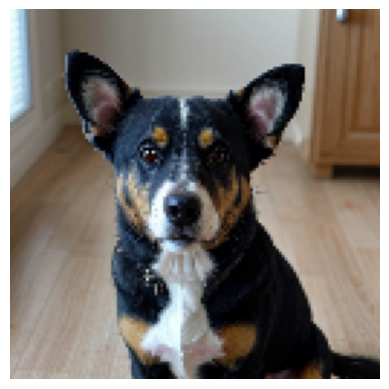

Prediction: Dog


In [30]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img_path = 'dog1.jpg.png'

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis('off')
plt.show()

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


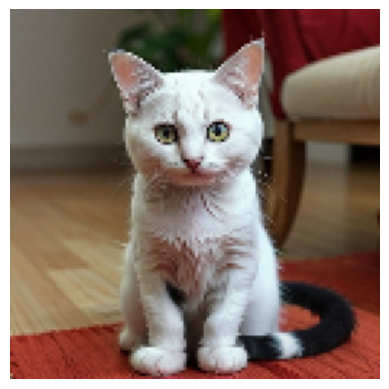

Prediction: Cat


In [31]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

img_path = 'cat1.jpg.png'

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis('off')
plt.show()

if prediction[0][0] > 0.5:
    print("Prediction: Dog")
else:
    print("Prediction: Cat")